<a href="https://colab.research.google.com/github/elhamod/BA820/blob/main/Text_Mining/Text_Mining_Applications_Basic_(edited).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Course: BA820 - Unsupervised and Unstructured ML**

**Notebook created by: Mohannad Elhamod**

# Book Review Dataset

For illustration purposes, we will use the reviews in [Goodread ratings dataset](https://huggingface.co/datasets/qmaruf/goodreads-rating) to practice text mining applications

## Loading The Data

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [165]:
!pip install datasets

In [166]:
from datasets import load_dataset

ds = load_dataset("qmaruf/goodreads-rating")

# get a random 10% subset
ds["train"] = ds["train"].to_pandas().sample(frac=0.2, random_state=42)

In [167]:
dataset_df = ds["train"]
dataset_df.drop(columns=["book_id", "user_id", "review_id", "date_added", "date_updated", "read_at", "started_at", "n_votes","n_comments"], inplace=True)

# only keep those with ratings 5 and 1
dataset_df = dataset_df[dataset_df["rating"].isin([5, 1])]

dataset_df = dataset_df.sample(frac=0.05, random_state=42)

In [168]:
dataset_df

,rating,review_text
349000,5,"An intro by stan lee, an amazing narration, in..."
290962,5,"Well, I think that J.L. made the original stor..."
281746,5,Jeff Zentner is one of those brilliantly worde...
772463,5,"Another great Poirot novel, brought to life in..."
437212,5,This just confirmed my all time love for Luka ...
...,...,...
213916,5,"Pepper has done it again ,I loved this book fr..."
104335,5,Spoilers alert: \n I just want to say : I FUCK...
300726,5,I've been meaning to read this book for a whil...
661469,5,Loved it! I am an avid Star Trek fan and alway...


A train/test split might be useful later.

In [169]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(dataset_df["review_text"], dataset_df["rating"], test_size=0.2, random_state=42)

## Sentiment Analysis (Unsupervised)

We will use a [`SentenceTransformer`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2), a deep learning model, to extract text embeddings.

In [170]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Examples
sentence = "What an exciting movie!"
embeddings = model.encode([sentence])
print(sentence, ". Embedding size:", embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

What an exciting movie! . Embedding size: (1, 384)


In [171]:
# Get the embedding for all reviews
embeddings_train = model.encode(X_train.to_list())
embeddings_test = model.encode(X_test.to_list())

Let's create two reference points for the positive vs. negative reviews and compare to them.

In [179]:
from sklearn.metrics.pairwise import cosine_similarity

positive_reference_embedding = model.encode("Really great and captivating. Loved it. I quite enjoyed it!").reshape(1, -1)
negative_reference_embedding = model.encode("Quite boring and got me sleepy. I would not recommend it.").reshape(1, -1)

def get_sentiment_score(embeddings):
  return cosine_similarity(positive_reference_embedding, embeddings) - cosine_similarity(negative_reference_embedding, embeddings)

training_scores = get_sentiment_score(embeddings_train)

threshold =  0.008212903


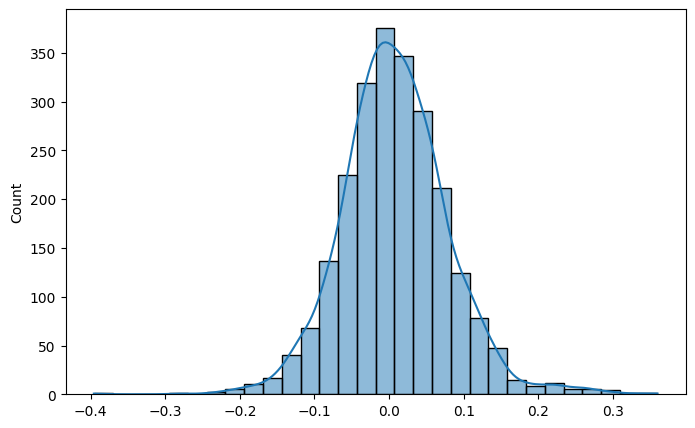

In [180]:
# Plot histogram of similarity scores
plt.figure(figsize=(8, 5))
sns.histplot(training_scores.reshape(-1), bins=30, kde=True)

threshold_train = np.mean(training_scores)
print("threshold = ", threshold_train)

Let's make sure this threshold works for the test set

In [181]:
test_scores = get_sentiment_score(embeddings_test)
threshold_test = np.mean(test_scores)
print("threshold = ", threshold_test)

threshold =  0.008729783


We could standardize to place the mean at zero.

In [182]:
from sklearn.preprocessing import StandardScaler

# Get the embeddings
embeddings = model.encode(dataset_df["review_text"].tolist())

# Get the scores
sentiment_score = get_sentiment_score(embeddings)

# Create Scalar
scaler = StandardScaler()
scaler.fit(training_scores.reshape(-1, 1))
# Scale the scores
dataset_df["sentiment_score"] =  scaler.transform(sentiment_score.reshape(-1, 1)).reshape(-1).tolist() # Get the sentiment score.

# Threshold the scores
dataset_df["positive?"] = dataset_df["sentiment_score"].apply(lambda x: "yes" if x > 0 else "no") # Threshold it.

In [183]:
dataset_df.sort_values(by="sentiment_score", ascending=False)

,rating,review_text,sentiment_score,positive?
849355,5,I loved this so much. It was wonderful (no pun...,4.920901,yes
82713,5,What a great story. It is so well done and bel...,4.554953,yes
206725,5,this was perfect.. loved the story.!!,4.554869,yes
822953,5,Loved it!,4.093313,yes
42935,5,Loved it!,4.093313,yes
...,...,...,...,...
871118,1,Not my kind of book..,-3.265795,no
780635,5,I like the ambivalence in this book. Huxley sh...,-3.308712,no
647678,1,just really disappointing and dull. :\,-3.480166,no
93939,1,"Boring, cliched, and not well-written. I could...",-4.024092,no


Let's see the distribution of sentiment vs. ratings

<Axes: xlabel='rating', ylabel='sentiment_score'>

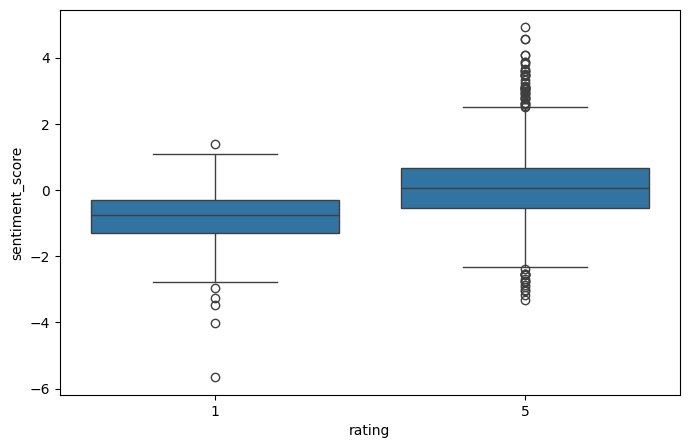

In [184]:
# show boxplot. x axis is rating. y axis is sentiment score
plt.figure(figsize=(8, 5))
sns.boxplot(x="rating", y="sentiment_score", data=dataset_df)

## **Questions:**

- How much do the ratings agree with the detected sentiments? How would you use the concepts you learned here to discard ratings that do not match with the review's sentiment?
- Would a mean pre-trained `word2vec` model yield good unsupervised sentiment analysis results? Why or why not?
- You are tasked with devising a way for detecting how political a review is. How would you go about implementing that?
- Can you find and use a pre-trained `huggingface` sentiment analysis model on this dataset? How does the pre-trained model compare to your unsupervised approach?